## IBM Telco Customer Churn Prediction
### 1. Giới thiệu dự án
**Bối cảnh dự án**

Trong ngành viễn thông, việc giữ chân khách hàng hiện tại thường có chi phí thấp hơn rất nhiều so với việc tìm kiếm khách hàng mới.

Tuy nhiên, nhiều khách hàng có xu hướng:

* hủy dịch vụ
* chuyển sang đối thủ cạnh tranh
* ngừng gia hạn hợp đồng
--> Hiện tượng này được gọi là: Customer Churn (khách hàng rời bỏ dịch vụ)

**Vấn đề của business**

Công ty viễn thông muốn:

* xác định trước những khách hàng có khả năng churn (rời bỏ dịch vụ)
* hiểu nguyên nhân khách hàng rời bỏ dịch vụ
* tối ưu chiến lược retention (giữ chân khách hàng)
Nhiệm vụ:

* phân tích dữ liệu khách hàng
* tìm ra các behavioral pattern (xu hướng hành vi)
* xây dựng machine learning model dự đoán churn

### 2. Thông tin tập dữ liệu (Dataset Information)
**Nguồn dữ liệu**

Dataset được sử dụng trong dự án là bộ dữ liệu IBM Telco Customer Churn Dataset, chứa thông tin khách hàng của một công ty viễn thông và hành vi sử dụng dịch vụ của họ. Mỗi dòng dữ liệu đại diện cho một khách hàng, bao gồm các nhóm thông tin như dữ liệu cá nhân cơ bản, loại dịch vụ đăng ký, thời gian sử dụng dịch vụ, phương thức thanh toán và chi phí sử dụng hàng tháng. Một số biến quan trọng trong tập dữ liệu gồm:

1. Nhóm thông tin khách hàng (Customer Information)

* customerID: Mã định danh duy nhất của từng khách hàng (Chuỗi ký tự).
* gender: Giới tính của khách hàng (Nam / Nữ).
* SeniorCitizen: Trạng thái người cao tuổi (1: Đúng, 0: Sai).
* Partner: Tình trạng hôn nhân / Có bạn đời hay chưa (Yes / No).
* Dependents: Có người phụ thuộc kinh tế hay không (Yes / No) (Ví dụ: con cái, cha mẹ già).
2. Nhóm thông tin dịch vụ (Service Information)

* PhoneService: Có đăng ký dịch vụ điện thoại cố định hay không (Yes / No).
* MultipleLines: Có sử dụng nhiều đường dây điện thoại đồng thời hay không (Yes / No / Không sử dụng dịch vụ điện thoại).
* InternetService: Nhà cung cấp dịch vụ Internet (DSL / Cáp quang [Fiber optic] / Không sử dụng Internet).
* OnlineSecurity: Có đăng ký dịch vụ bảo mật trực tuyến hay không (Yes / No / Không sử dụng Internet).
* OnlineBackup: Có đăng ký dịch vụ sao lưu dữ liệu trực tuyến hay không (Yes / No / Không sử dụng Internet).
* DeviceProtection: Có đăng ký gói bảo hiểm/bảo vệ thiết bị hay không (Yes / No / Không sử dụng Internet).
* TechSupport: Có sử dụng dịch vụ hỗ trợ kỹ thuật chuyên sâu hay không (Yes / No / Không sử dụng Internet).
* StreamingTV: Có sử dụng dịch vụ truyền hình trực tuyến hay không (Yes / No / Không sử dụng Internet).
* StreamingMovies: Có sử dụng dịch vụ xem phim trực tuyến trực tuyến hay không (Yes / No / Không sử dụng Internet).
3. Nhóm thông tin tài khoản và cước phí (Account & Financial Information)

* tenure: Số tháng khách hàng đã gắn bó và sử dụng dịch vụ tại công ty (Biến số lượng).
* Contract: Loại hợp đồng theo thời hạn ký kết (Theo từng tháng [Month-to-month] / 1 năm / 2 năm).
* PaperlessBilling: Sử dụng hình thức nhận hóa đơn điện tử thay cho hóa đơn giấy hay không (Yes / No).
* PaymentMethod: Phương thức thanh toán cước phí (Séc điện tử [Electronic check], Séc qua thư [Mailed check], Thẻ tín dụng tự động [Credit card], Chuyển khoản ngân hàng tự động [Bank transfer]).
* MonthlyCharges: Số tiền cước phí phải trả hằng tháng (Biến số lượng).
* TotalCharges: Tổng số tiền cước tích lũy đã trả trong suốt thời gian sử dụng dịch vụ (Biến số lượng).
Cột mục tiêu của dự án:

Churn: Trạng thái rời bỏ hoặc tiếp tục gắn bó của khách hàng (Biến phân loại nhị phân).
* Yes: Khách hàng đã chấm dứt hợp đồng và rời bỏ dịch vụ.
* No: Khách hàng vẫn đang tiếp tục sử dụng dịch vụ của công ty.

### Phan 1: IMPORT Thu Vien

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [204]:
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

### Phan 2: Doc Du lieu

In [205]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [206]:
profile = ProfileReport(df,title="Customer_Churn", explorative=True)
profile.to_file("Customer_Churn.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 311.59it/s]


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [208]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [209]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [210]:
df.duplicated().sum()

np.int64(0)

In [211]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [212]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [213]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

TotalCharges    11
dtype: int64

In [214]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [215]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

### Phan 3: EDA (Exploratory Data Analysis - Phân tích khám phá dữ liệu)

Text(0, 0.5, 'Số tháng gắn bó')

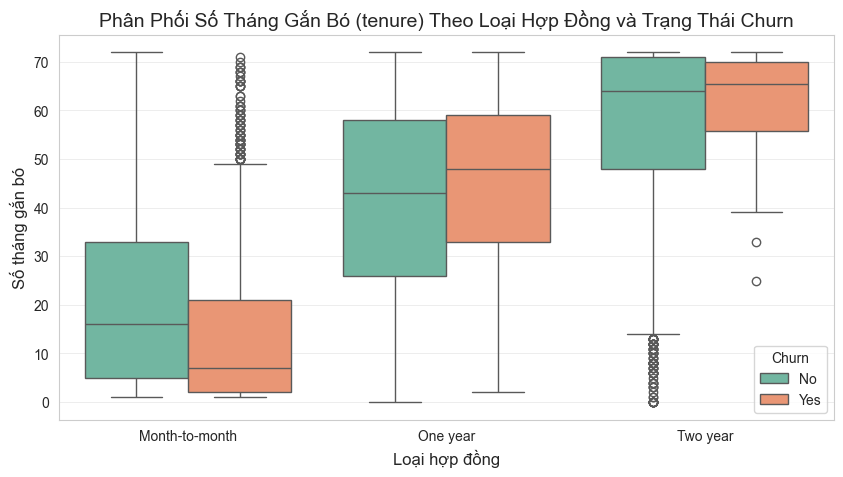

In [216]:
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df, palette='Set2')
plt.title('Phân Phối Số Tháng Gắn Bó (tenure) Theo Loại Hợp Đồng và Trạng Thái Churn')
plt.xlabel('Loại hợp đồng')
plt.ylabel('Số tháng gắn bó')

Phân tích Insight

Hợp đồng Month-to-month: Đây là "vùng nguy hiểm nhất" của doanh nghiệp. Nhóm khách hàng rời đi (màu cam) tập trung cực kỳ đông ở giai đoạn rất mới (hộp nằm rất thấp, trung vị cắm dưới 10 tháng). Nghĩa là đối với hợp đồng theo tháng, nếu khách hàng không hài lòng trong vài tháng đầu, họ sẽ rời đi ngay lập tức.

Hợp đồng 1 năm & 2 năm (One year / Two year): Thời hạn hợp đồng có tác dụng "khóa chân" khách hàng cực tốt. Hãy nhìn vào nhóm hợp đồng 2 năm: phần lớn khách hàng ở lại (màu xanh) có số tháng gắn bó chạm trần (60-70 tháng).

Điểm bất thường đáng chú ý: Ở nhóm hợp đồng 2 năm, vẫn xuất hiện một số khách hàng rời đi (màu cam). Nhưng hãy nhìn vào hộp màu cam đó: trung vị của nó rất cao (khoảng >65 tháng). Điều này chứng tỏ họ chỉ rời đi sau khi đã hoàn thành trọn vẹn thời hạn cam kết (hết 2 năm, rồi thêm chu kỳ mới) chứ không phải phá vỡ hợp đồng giữa chừng.

Text(0, 0.5, 'Cước phí hàng tháng (Monthly Charges)')

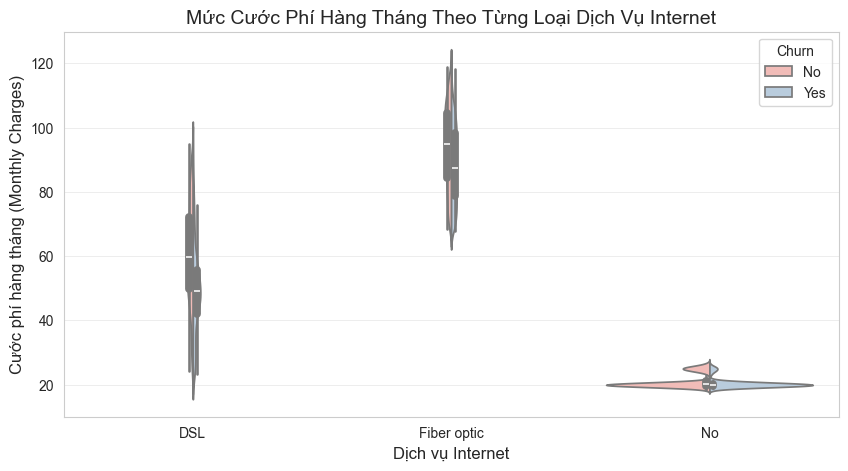

In [217]:
sns.violinplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df, split=True, palette='Pastel1')
plt.title('Mức Cước Phí Hàng Tháng Theo Từng Loại Dịch Vụ Internet')
plt.xlabel('Dịch vụ Internet')
plt.ylabel('Cước phí hàng tháng (Monthly Charges)')

Phân tích Insight

Cáp quang (Fiber optic) - "Ngòi nổ" Churn: Hãy nhìn vào hình dáng của cột Fiber optic, nó phình rất to ở phân khúc cước phí cực cao (từ 80 đến trên 100 USD/tháng). Nghiêm trọng hơn, dải màu xanh dương (Churn) và màu hồng (No Churn) lồng hẳn vào nhau với mật độ dày đặc ở mức giá cao. Điều này khẳng định: Cước phí cáp quang quá đắt chính là lý do trực tiếp đẩy khách hàng rời mạng.

Dịch vụ DSL: Mức cước dễ thở hơn (40 - 70 USD). Hình dáng violin cho thấy khách hàng tương đối ổn định, tỷ lệ Churn phân bố đều và không có sự đột biến.

Không dùng Internet (No): Cước phí rẻ mạt (quanh mức 20 USD). Nhóm này gần như phẳng lặng, tỷ lệ rời đi cực kỳ thấp.

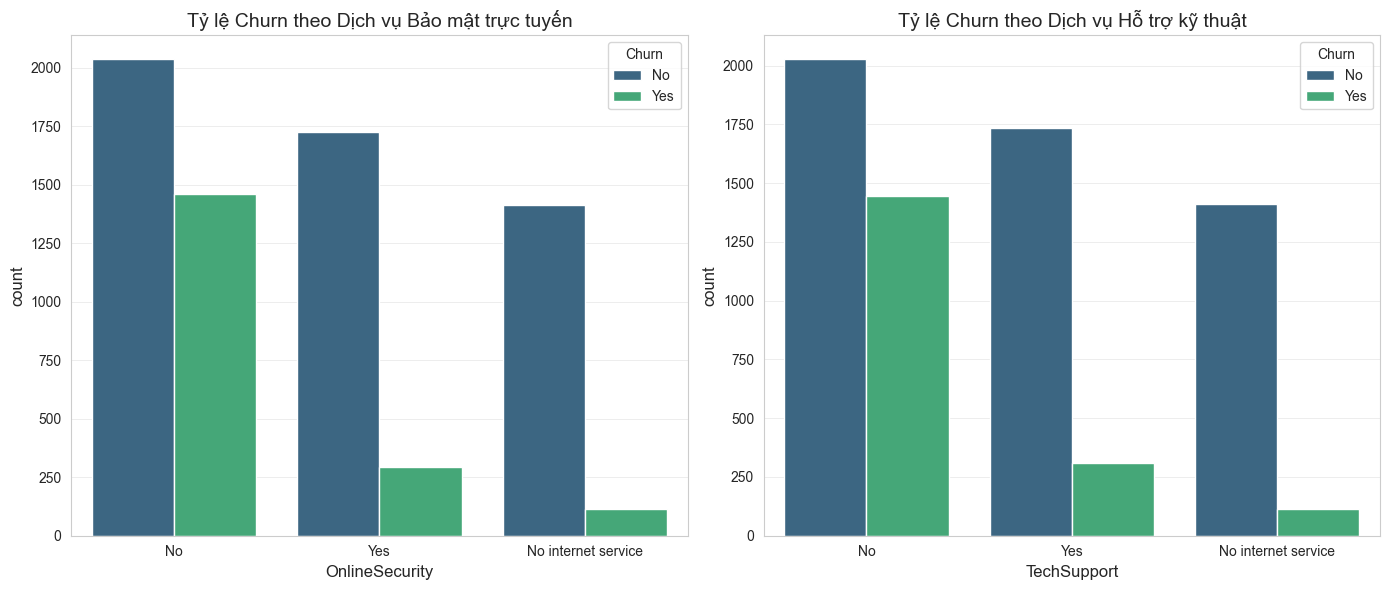

In [218]:
# Ví dụ vẽ cho 2 biến tiêu biểu: OnlineSecurity và TechSupport
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='OnlineSecurity', hue='Churn', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Tỷ lệ Churn theo Dịch vụ Bảo mật trực tuyến')

sns.countplot(x='TechSupport', hue='Churn', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Tỷ lệ Churn theo Dịch vụ Hỗ trợ kỹ thuật')

plt.tight_layout()
plt.show()

Phân tích Insight

Hai biểu đồ này có cấu trúc giống hệt nhau và phản ánh một sự thật phũ phàng: Khách hàng không mua dịch vụ bảo vệ sẽ không có cảm giác an toàn.

Nhóm "No" (Không đăng ký bảo mật/hỗ trợ kỹ thuật): Số lượng khách hàng Churn (cột màu xanh lá) cao kinh khủng, gần bằng một nửa số người ở lại.

Nhóm "Yes" (Có đăng ký): Cột Churn (xanh lá) sụt giảm một cách rõ rệt, chỉ còn chiếm một tỷ lệ rất nhỏ so với cột ở lại (xanh dương).

Kết luận: Dù các dịch vụ này làm tăng nhẹ cước phí, nhưng chúng lại đóng vai trò là "chất keo" giữ chân khách hàng cực kỳ mạnh mẽ. Khi khách hàng được hỗ trợ kỹ thuật tốt và hệ thống mạng an toàn, họ rất ngại chuyển sang nhà mạng khác.

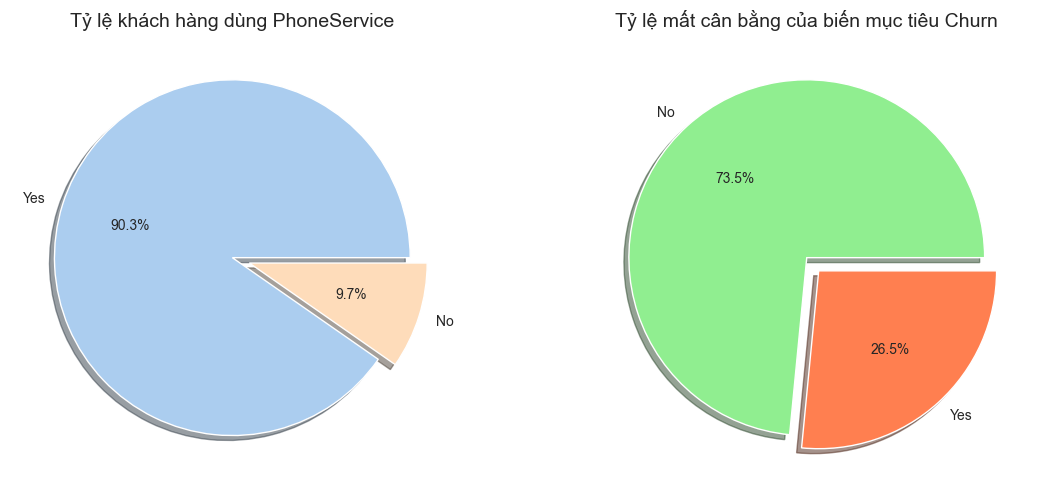

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Kiểm tra PhoneService (Trục bên trái)
df['PhoneService'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=axes[0], shadow=True, colors=['#abcdef', '#fedcba']
)
axes[0].set_title('Tỷ lệ khách hàng dùng PhoneService')
axes[0].set_ylabel('')

df['Churn'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=axes[1], shadow=True, colors=['lightgreen', 'coral']
)
axes[1].set_title('Tỷ lệ mất cân bằng của biến mục tiêu Churn')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


Biểu đồ mục tiêu Churn (73.5% No vs 26.5% Yes): Đây là tỷ lệ mất cân bằng điển hình của bài toán Churn thực tế trong doanh nghiệp. Lớp thiểu số (Churn = Yes) chỉ chiếm khoảng 1/4 dữ liệu.
Do biến mục tiêu Churn bị lệch (73.5% vs 26.5%), khi huấn luyện mô hình máy học, bạn tuyệt đối không được dùng chỉ số Accuracy làm thước đo chính.
Bắt buộc phải sử dụng chỉ số F1-Score / Recall và áp dụng kỹ thuật cân bằng dữ liệu như SMOTE hoặc thiết lập tham số class_weight='balanced' trong mô hình.

### Phan 4: Feature Selection

In [220]:
customer_id_train_test = df["customerID"]
df = df.drop(columns=["customerID"])

In [221]:
# 1. Tạo biến tổng hợp đếm số lượng dịch vụ gia tăng (Add-on Services)
addon_features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Đếm xem khách hàng có bao nhiêu dịch vụ dạng 'Yes'
df['Total_Addon_Services'] = (df[addon_features] == 'Yes').sum(axis=1)

# 2. Sau khi đã gom thông tin, ta có thể tự tin loại bỏ các biến thành phần
# để giảm số lượng chiều dữ liệu (Dimensionality Reduction)
df = df.drop(columns=addon_features)

In [222]:
def tenure_group(tenure):

    if tenure <= 12:
        return 'New Customer'

    elif tenure <= 36:
        return 'Mid-term Customer'

    else:
        return 'Loyal Customer'


df['tenure_group'] = df['tenure'].apply(tenure_group)

In [223]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_Addon_Services,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,New Customer
1,Male,0,No,No,34,Yes,No,DSL,One year,No,Mailed check,56.95,1889.50,No,2,Mid-term Customer
2,Male,0,No,No,2,Yes,No,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,New Customer
3,Male,0,No,No,45,No,No phone service,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,Loyal Customer
4,Female,0,No,No,2,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,New Customer


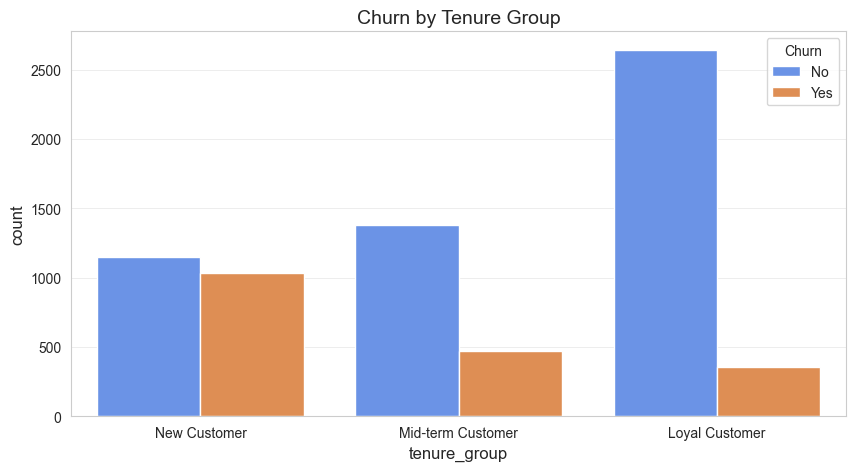

In [224]:
sns.countplot(
    data=df,
    x='tenure_group',
    hue='Churn'
)

plt.title('Churn by Tenure Group')

plt.show()

Khách hàng mới (New Customer): Có số lượng churn nhiều hơn đáng kể, chiếm tỷ lệ gần tương đương với nhóm ở lại do chưa kịp hình thành lòng trung thành (loyalty).
Khách hàng trung thành (Loyal Customer): Có tỷ lệ churn thấp hơn hẳn, phần lớn lựa chọn tiếp tục gắn bó với dịch vụ.
Kết luận: Chiến lược giữ chân (retention strategy) cần phải tập trung nguồn lực mạnh mẽ vào giai đoạn đầu của vòng đời khách hàng (customer lifecycle).

### Phan 5: Chia tap train-test

In [225]:
target = "Churn"
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [226]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Phan 6: DATA PREPROCESSING

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                7043 non-null   object 
 1   SeniorCitizen         7043 non-null   int64  
 2   Partner               7043 non-null   object 
 3   Dependents            7043 non-null   object 
 4   tenure                7043 non-null   int64  
 5   PhoneService          7043 non-null   object 
 6   MultipleLines         7043 non-null   object 
 7   InternetService       7043 non-null   object 
 8   Contract              7043 non-null   object 
 9   PaperlessBilling      7043 non-null   object 
 10  PaymentMethod         7043 non-null   object 
 11  MonthlyCharges        7043 non-null   float64
 12  TotalCharges          7043 non-null   float64
 13  Churn                 7043 non-null   object 
 14  Total_Addon_Services  7043 non-null   int64  
 15  tenure_group         

In [228]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [229]:
nom_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(sparse_output=True))
])

In [230]:
numeric_features = x.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = x.select_dtypes(
    include=['object']
).columns

In [231]:
ct = ColumnTransformer(transformers=[
    ("num", num_transformer, numeric_features),
    ("nom", nom_transformer, categorical_features)
])

In [232]:
reg = Pipeline(steps=[
    ("preprocessor", ct)
])

In [233]:
# 1. Fit và transform dữ liệu training, chỉ transform dữ liệu test để tránh leak dữ liệu
x_train_preprocessed = reg.fit_transform(x_train)
x_test_preprocessed = reg.transform(x_test)

# 2. Khởi tạo LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# 3. Truyền dữ liệu ĐÃ QUA XỬ LÝ vào đây
models, predictions = clf.fit(x_train_preprocessed, x_test_preprocessed, y_train, y_test)

# 4. Sắp xếp theo Recall (Trong bảng của bạn có hẳn cột 'Recall' kìa, dùng luôn nhé!)
models_sorted = models.sort_values(by='Recall', ascending=False)
models_sorted

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LogisticRegression,0.799148,0.710454,0.842106,0.791468,0.789218,0.799148,0.035441
RidgeClassifier,0.796309,0.690591,0.836330,0.783458,0.783548,0.796309,0.028571
CalibratedClassifierCV,0.796309,0.695714,0.838870,0.785149,0.784132,0.796309,0.138618
LinearSVC,0.796309,0.695714,0.838818,0.785149,0.784132,0.796309,0.038195
RidgeClassifierCV,0.796309,0.690591,0.836330,0.783458,0.783548,0.796309,0.031810
SVC,0.795600,0.686693,0.808957,0.781671,0.782477,0.795600,0.676835
AdaBoostClassifier,0.794180,0.713049,0.841428,0.788789,0.786101,0.794180,0.471670
LinearDiscriminantAnalysis,0.794180,0.701949,0.836294,0.785685,0.783323,0.794180,0.049799
RandomForestClassifier,0.789922,0.691366,0.820476,0.779661,0.777544,0.789922,0.400070


Lua chon mo hinh LogisticRegression de huan luyen mo hinh

In [234]:
reg = Pipeline(steps=[
    ("preprocessor", ct),
    ("model", LogisticRegression(solver='lbfgs', multi_class='multinomial'))
])

In [235]:
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l2'],                   # 'lbfgs' chỉ hỗ trợ l2 hoặc None
    'model__max_iter': [100, 200, 500]
}

In [236]:
grid_search = GridSearchCV(estimator=reg,param_grid=param_grid, scoring="recall_weighted", n_jobs=-1, cv=5, verbose=2)
grid_result = grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Fr

[CV] END model__C=0.01, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=100, model__penalty=l2; total time=   0.2s
[CV] END model__C=0.01, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=100, model__penalty=l2; total time=   0.2s
[CV] END model__C=0.01, model__max_iter=200, model__penalty=l2; total time=   0.2s
[CV] END model__C=0.01, model__max_iter=100, model__penalty=l2; total time=   0.2s
[CV] END model__C=0.01, model__max_iter=100, model__penalty=l2; total time=   0.1s


/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Fr

[CV] END model__C=0.01, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.01, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.1, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.1, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.1, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.1, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=0.1, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END 

...

/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Fr

[CV] END model__C=1.0, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=1.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END mod

/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Fr

[CV] END model__C=10.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=10.0, model__max_iter=500, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=100, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=200, model__penalty=l2; total time=   0.1s
[CV] END model__C=100.0, model__max_iter=200, model__penalty=l2; total time=   0

/opt/anaconda3/envs/machine-learning-vietnguyen/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [237]:
print(f"Best score: {grid_result.best_score_}")
print(grid_result.best_params_)

y_pred = grid_search.predict(x_test)

Best score: 0.8049326951415365
{'model__C': 10.0, 'model__max_iter': 100, 'model__penalty': 'l2'}


In [238]:
print("=================== CLASSIFICATION REPORT ===================")
print(classification_report(y_test, y_pred, target_names=['Ở lại (No)', 'Rời đi (Yes)']))

=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

  Ở lại (No)       0.84      0.90      0.87      1035
Rời đi (Yes)       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



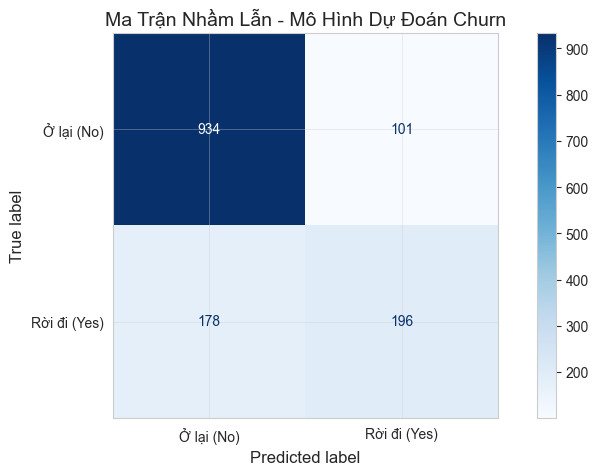

In [239]:
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ở lại (No)', 'Rời đi (Yes)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Ma Trận Nhầm Lẫn - Mô Hình Dự Đoán Churn')
plt.show()

Dự đoán đúng Khách hàng ở lại (True Negative = 934): Mô hình nhận diện rất tốt những người trung thành không có ý định rời đi.

Dự đoán đúng Khách hàng rời đi (True Positive = 196): Đây là 196 khách hàng nguy cơ cao mà hệ thống đã "bắt" trúng, phòng Marketing có thể can thiệp ngay lập tức để giữ chân họ.

Báo động giả (False Positive = 101): Có 101 người thực tế không rời đi nhưng mô hình đoán nhầm là có. Tỷ lệ này hoàn toàn chấp nhận được, doanh nghiệp chỉ tốn thêm một chút chi phí ưu đãi cho họ mà không sợ mất khách hàng.

Bỏ sót nguy hiểm (False Negative = 178): Đây là lỗ hổng lớn nhất. Có 178 khách hàng thực tế sẽ rời mạng nhưng mô hình lại đoán là họ sẽ ở lại. Doanh nghiệp sẽ mất trắng 178 người này nếu không có biện pháp khác.

Kết luận: Mô hình hiện tại hoạt động an toàn nhưng còn khá "thận trọng" (chỉ bắt được hơn một nửa số ca thực tế rời đi).

In [240]:
import pandas as pd

# 1. Lấy mô hình tốt nhất từ Grid Search
best_model = grid_result.best_estimator_

# 2. Trích xuất chính xác tên các tính năng SAU KHI ĐÃ ĐI QUA PIPELINE
# Biến [:-1] có nghĩa là lấy tất cả các bước tiền xử lý, bỏ qua bước classifier cuối cùng
try:
    feature_names = best_model[:-1].get_feature_names_out()
except Exception:
    # Nếu dùng phiên bản scikit-learn cũ hơn không có get_feature_names_out
    # Ta sẽ lấy từ bước đặt tên cụ thể (thường là columntransformer)
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# 3. Tạo DataFrame mà không lo bị lệch độ dài nữa
importance_df = pd.DataFrame({
    'Tính năng (Feature)': feature_names,
    'Trọng số (Coefficient)': best_model[-1].coef_[0]
})

# 4. Sắp xếp theo mức độ tác động từ lớn đến nhỏ
importance_df = importance_df.sort_values(by='Trọng số (Coefficient)', ascending=False)

# 5. In kết quả
print("=================== BẢNG TRỌNG SỐ CHÍNH XÁC ===================")
print(importance_df.to_string(index=False))

=================== BẢNG TRỌNG SỐ CHÍNH XÁC ===================
                         Tính năng (Feature)  Trọng số (Coefficient)
                         num__MonthlyCharges                1.092971
                     nom__InternetService_No                0.465923
                nom__Contract_Month-to-month                0.330754
         nom__MultipleLines_No phone service                0.242090
                        nom__PhoneService_No                0.242090
            nom__tenure_group_Loyal Customer                0.191568
                           num__TotalCharges                0.146917
         nom__PaymentMethod_Electronic check                0.116177
                   nom__PaperlessBilling_Yes                0.042773
                          num__SeniorCitizen                0.033321
                          nom__Dependents_No               -0.002270
                      nom__Contract_One year               -0.036413
                            nom__Partne

**Top 1: Cước phí hàng tháng (num__MonthlyCharges = 1.09)**

Insight: Đây là yếu tố có tác động mạnh mẽ nhất đến quyết định rời mạng của khách hàng (Hệ số > 1). Cứ mỗi khi cước phí hàng tháng tăng lên, áp lực tài chính khiến khách hàng ngay lập tức có xu hướng tìm kiếm đối thủ cạnh tranh có giá rẻ hơn.

Hành động: Doanh nghiệp không thể chỉ đơn thuần giảm giá vô điều kiện vì sẽ mất doanh thu. Thay vào đó, hãy thiết kế các gói cước Combo hoặc Gia đình (Ví dụ: Tích hợp Internet + Thoại cố định + Data di động) để khách hàng cảm thấy số tiền họ bỏ ra nhận lại được nhiều giá trị hơn.

**Top 2: Loại hợp đồng ngắn hạn (nom__Contract_Month-to-month = 0.33)**

Insight: Khách hàng ký hợp đồng cuốn chiếu theo từng tháng cực kỳ kém trung thành. Vì không có ràng buộc về mặt pháp lý hay chi phí phạt hủy hợp đồng, họ sẵn sàng rời đi bất cứ lúc nào.

Hành động: Triển khai chiến dịch chuyển đổi: Tặng ngay 1 tháng cước miễn phí hoặc giảm giá 10% tổng hóa đơn nếu khách hàng đồng ý nâng cấp từ hợp đồng tháng lên hợp đồng cam kết 1 năm hoặc 2 năm.

**Top 3: Phương thức thanh toán bằng Séc điện tử (nom__PaymentMethod_Electronic check = 0.11)**

Insight: Thanh toán bằng séc điện tử yêu cầu khách hàng phải chủ động thực hiện hành vi trả tiền mỗi tháng. Mỗi lần nhìn vào hóa đơn và thao tác thanh toán là một lần họ cân nhắc xem dịch vụ này có đáng tiền không.

Hành động: Khuyến khích khách hàng chuyển sang hình thức Thanh toán tự động (Auto-pay) thông qua thẻ tín dụng hoặc liên kết ngân hàng. Doanh nghiệp có thể tặng voucher chiết khấu 5% cho kỳ hóa đơn đầu tiên khi khách hàng đăng ký Auto-pay thành công.